In [1]:
import numpy as np
from pathlib import Path
import reciprocalspaceship as rs
from meteor import rsmap
import gemmi
from meteor.sfcalc import gemmi_structure_to_calculated_map

from configuration import load_homepath

%load_ext autoreload
%autoreload 2

In [2]:
synthloc = load_homepath() + "synthetic_cistrans/"
pdbloc_dark = synthloc + "trans.pdb"
pdbloc_light = synthloc + "100ps.pdb"
snr_factor = 7  # SNR at 2 Angstrom


In [3]:
high_resolution_limit = 1.5
struc_dark = gemmi.read_pdb(pdbloc_dark)
map_dark = gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=high_resolution_limit
)
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)

struc_light = gemmi.read_pdb(pdbloc_light)
map_light = gemmi_structure_to_calculated_map(
    struc_light, high_resolution_limit=high_resolution_limit
)
map_light_np = map_light.to_3d_numpy_map(map_sampling=3)


In [4]:
np.mean(map_light_np), np.std(map_light_np)


(np.float32(0.22628874), np.float32(0.35649475))

In [5]:
file_loc = synthloc + "trans_noise3.mtz"
ds = rs.read_mtz(file_loc)
(ds.dtypes)

F_k           SFAmplitude
SIGF_k             Stddev
PHI_k               Phase
FreeR_flag         MTZInt
SIGFC              Stddev
dtype: object

In [6]:
import matplotlib.pyplot as plt
from create_noisy_synth_data import make_clean_synthetic_data

list_of_dicts = []
diff_clean, map_dark_clean, map_light_clean = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    high_resolution_limit=1.5,
    dark_phases=False,
    snr_factor=0,
)

options = dict(
        high_resolution_limit=1.5,
        dark_phases=True,
        snr_factor=20,
        noise_type="floor",
)
for _ in range(16):
    diffmap, map_dark, _ = make_clean_synthetic_data(
        pdbloc_dark,
        pdbloc_light,
        **options
    )
    diffmap.drop((0, 0, 0), inplace=True)
    # print(map_dark)
    # print(map_dark_clean)
    map_dark.loc[(0, 0, 0), "F"] = map_dark_clean.loc[(0, 0, 0), "F"]

    map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
    pseudo_occupancy = -diffmap_np / map_dark_np

    list_of_dicts.append(
        {
            "diffmap": diffmap,
            "map_dark": map_dark,
            "map_dark_np": map_dark_np,
            "diffmap_np": diffmap_np,
            "pseudo_occupancy": pseudo_occupancy,
        }
    )

In [7]:
diff_clean, map_dark_clean, map_light_clean = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    high_resolution_limit=1.5,
    dark_phases=False,
    snr_factor=0,
)

diff_clean_dark, _, _ = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    high_resolution_limit=1.5,
    dark_phases=True,
    snr_factor=0,
)
diff_clean_np = diff_clean.to_3d_numpy_map(map_sampling=3)
diff_clean_dark_np = diff_clean_dark.to_3d_numpy_map(map_sampling=3)
clean_mask = np.abs(diff_clean_np) >0.1
default_mean = np.mean(diff_clean_dark_np[clean_mask])


16
0 -7.358598e-12
1 -7.358598e-12
2 -7.358598e-12
3 -1.4717196e-11
4 7.358598e-12
5 -2.9434392e-11
6 3.679299e-12
7 0.0
8 1.4717196e-11
9 1.4717196e-11
10 -2.9434392e-11
11 2.9434392e-11
12 0.0
13 0.0
14 0.0
15 -1.4717196e-11


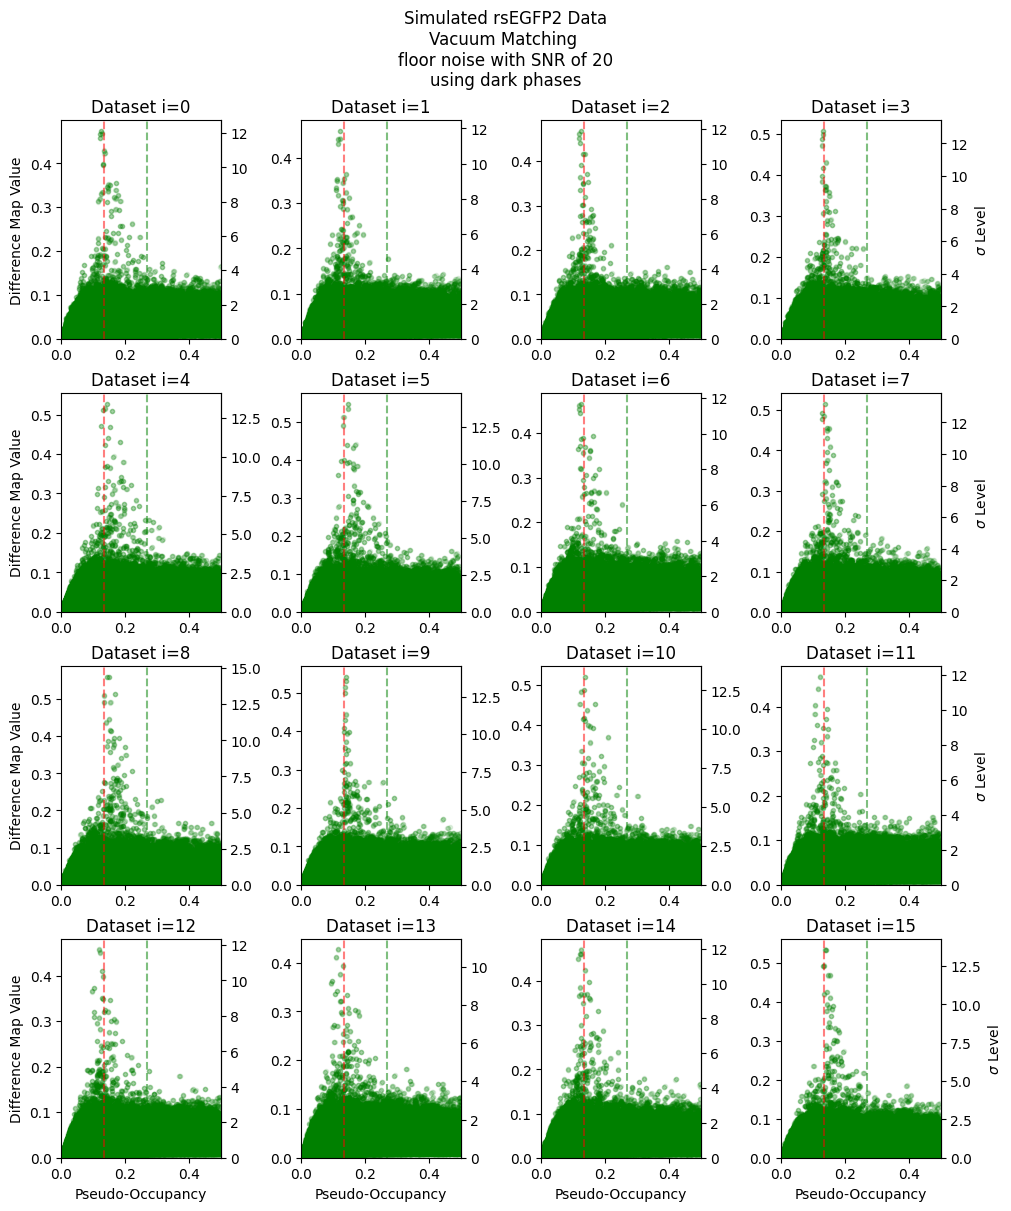

In [8]:
xmin = 0
ymin = 0
xmax = 0.5

fig, axs = plt.subplots(4,4, figsize=(10,12), constrained_layout = True)
print(len(list_of_dicts))
for i, (dl, ax) in enumerate(zip(list_of_dicts, axs.flat)):
    pseudo = dl['pseudo_occupancy']
    diff = -dl['diffmap_np']
    
    
    # 2. Calculate stats LOCALLY for this specific subplot
    current_mean = np.mean(diff)
    current_std = np.std(diff)
    current_mean_peak = np.mean(diff[clean_mask]) - default_mean
    print(i, current_mean)
    
    # 3. Define the transformation functions with local closure
    # We use default arguments to "snap" the current mean/std into the function
    def abs_to_std(y, m=current_mean, s=current_std):
        return (y - m) / s

    def std_to_abs(z, m=current_mean, s=current_std):
        return (z * s) + m
    sig3 = std_to_abs(0.2)
    mask = np.logical_and.reduce([diff > ymin, pseudo > xmin, pseudo < xmax])
    mask_main = np.logical_and(mask, diff<sig3)
    mask_outlier = np.logical_and(mask, diff>=sig3)
    
    # 1. Plot the data
    ax.plot(pseudo[mask_outlier], diff[mask_outlier], '.', color='green', alpha=0.1)
    # ax.plot(pseudo[mask_main], diff[mask_main], ',', color='green', alpha=0.1)


    # 4. Vertical lines and limits
    ax.axvline(0.135, color='red', linestyle='--', alpha=0.5)
    ax.axvline(0.27, color='green', linestyle='--', alpha=0.5)
    ax.set_ylim(0, None)
    ax.set_xlim(xmin, xmax)
    title_ax = f"Dataset i={i}"
    # title_ax += f"\n Mean: {current_mean*100:.4f}"
    # title_ax += f"\n Mean Peak: {current_mean_peak*100:.4f}"
    ax.set_title(title_ax)
    secax = ax.secondary_yaxis('right', functions=(abs_to_std, std_to_abs))
    if (i + 1) % 4 == 0: 
        secax.set_ylabel(r"$\sigma$ Level", fontsize=10)
    # secax.set_ylabel(r"Standard Deviations ($\sigma$)")
for ax in axs[-1, :]:
    ax.set_xlabel("Pseudo-Occupancy")
for ax in axs[:,0]:
    ax.set_ylabel("Difference Map Value")

title = "Simulated rsEGFP2 Data\n"
title += f"Vacuum Matching \n{options['noise_type']} noise with SNR of {options['snr_factor']}\n"
title += f"using {'dark' if options['dark_phases'] else 'true'} phases"
_ =fig.suptitle(title)

16


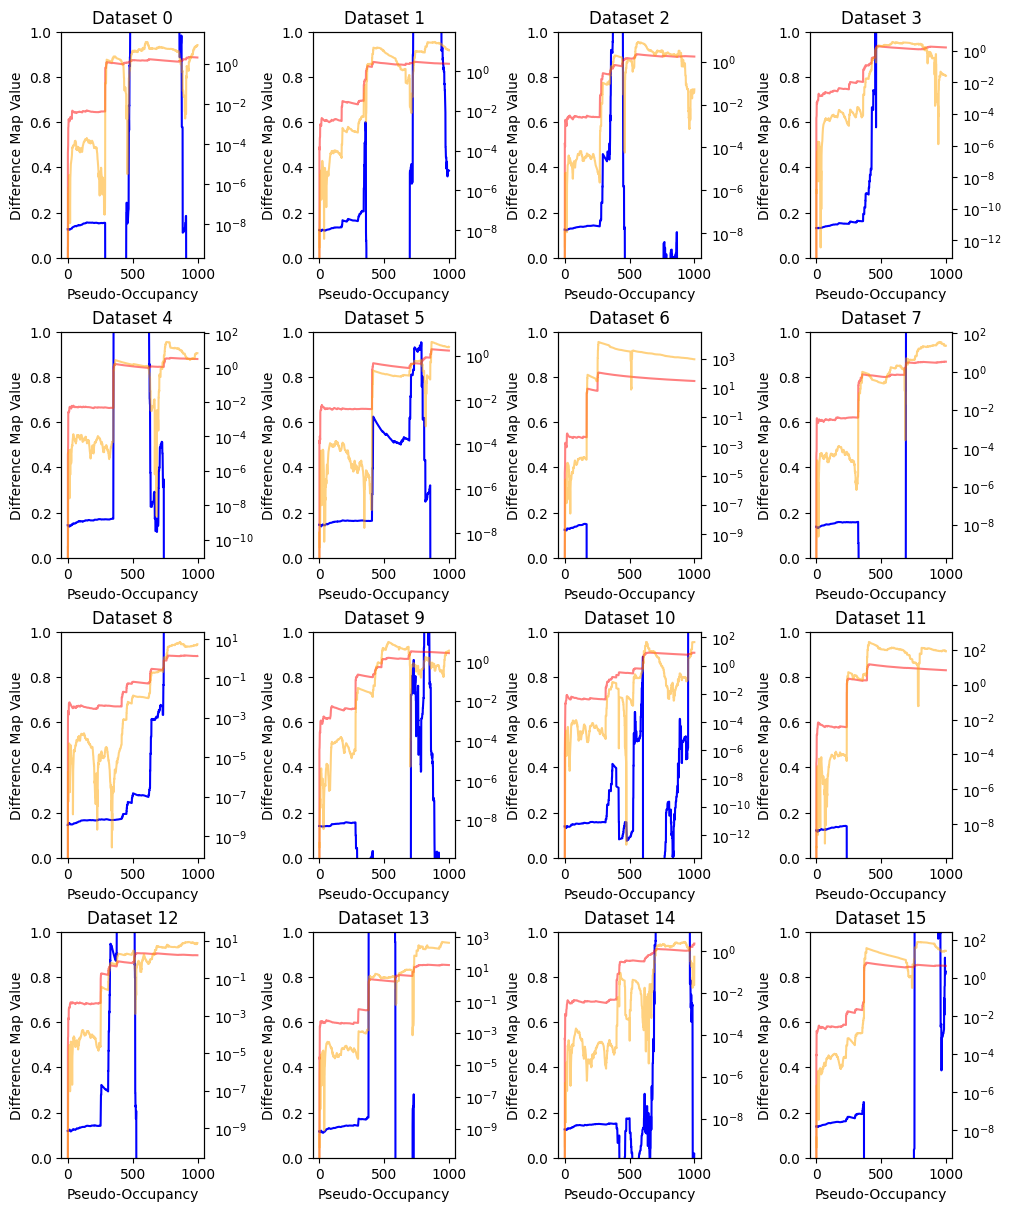

In [9]:
xmin = 0
ymin = 0
xmax = 0.5

fig, axs = plt.subplots(4,4, figsize=(10,12), constrained_layout = True)
print(len(list_of_dicts))
for i, (dl, ax) in enumerate(zip(list_of_dicts, axs.flat)):
    pseudo = dl['pseudo_occupancy'].flatten()
    diff = -dl['diffmap_np'].flatten()

    argsorted = np.argsort(diff)[::-1][:1000]

    pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
    pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
    pseudo_std = [pseudo[argsorted][:x].std() for x in range(1,len(argsorted)+1)]
    pseudo_ste = pseudo_std/np.sqrt(np.arange(1,len(argsorted)+1))*2
    bias_term = [(pseudo_sort[i] - pseudo_sort[i//2])**2 for i in range(len(pseudo_sort))]
    # ax.plot(diff[argsorted],pseudo_sort, label='Cumulative Pseudo-Occupancy', color='blue')
    ax.plot(pseudo_sort, label='Cumulative Pseudo-Occupancy', color='blue')
    ax.set_ylim(0,1)
    ax2 = ax.twinx()
    # ax2.plot(diff[argsorted], label='Cumulative Pseudo-Occupancy', color='green', alpha=0.5)
    ax2.plot(pseudo_ste, label='Cumulative Pseudo-Occupancy', color='red', alpha=0.5)
    ax2.plot(bias_term, label='Cumulative Pseudo-Occupancy', color='orange', alpha=0.5)
    ax2.set_yscale('log')
    ax.set_xlabel("Pseudo-Occupancy")
    ax.set_ylabel("Difference Map Value")
    ax.set_title(f"Dataset {i}")


Text(0.5, 0, 'Clean Difference Map Values/2')

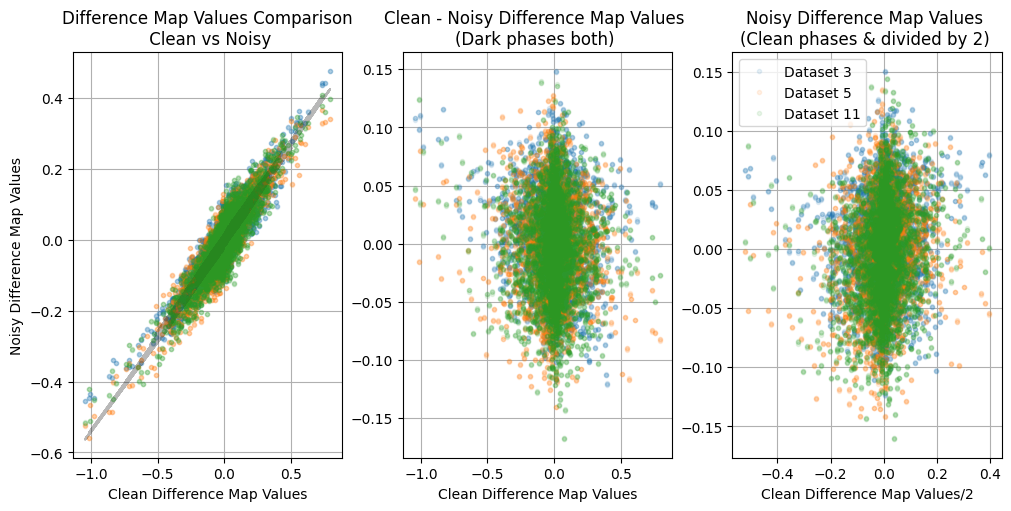

In [119]:
clean_mask = np.abs(diff_clean_np) > 0.01
default_mean = np.mean(diff_clean_np[clean_mask])
fig, axs = plt.subplots(1,3, figsize = (10,5), constrained_layout=True)
for i, (dl) in enumerate((list_of_dicts)):
    if i in [3,5,11,]:
        pseudo = dl['pseudo_occupancy']
        diff = dl['diffmap_np']
        axs[0].plot(diff_clean_np[clean_mask], diff[clean_mask], '.', alpha=0.1, label =f"Dataset {i}")
        axs[0].plot(diff_clean_np[clean_mask], diff_clean_dark_np[clean_mask], '-k', alpha=0.1,)
        axs[1].plot(diff_clean_np[clean_mask], diff[clean_mask]-diff_clean_dark_np[clean_mask], '.', alpha=0.1, label =f"Dataset {i}")
        axs[2].plot(diff_clean_np[clean_mask]/2, diff[clean_mask]-diff_clean_np[clean_mask]/2, '.', alpha=0.1, label =f"Dataset {i}")
axs[2].legend()
axs[0].set_xlabel("Clean Difference Map Values")
axs[0].set_ylabel("Noisy Difference Map Values")
axs[0].set_title("Difference Map Values Comparison\n Clean vs Noisy")
axs[1].set_xlabel("")
axs[1].set_title("Clean - Noisy Difference Map Values \n(Dark phases both) ")
axs[2].set_title("Noisy Difference Map Values \n(Clean phases & divided by 2) ")

axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].set_xlabel("Clean Difference Map Values")
axs[1].set_xlabel("Clean Difference Map Values")
axs[2].set_xlabel("Clean Difference Map Values/2")

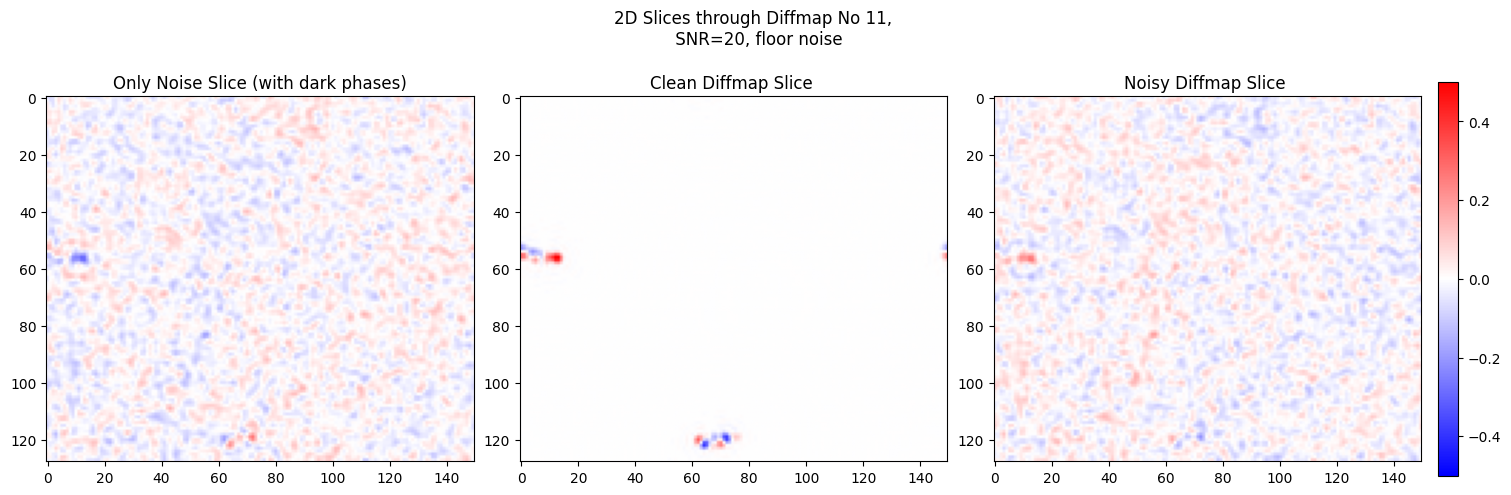

In [120]:
from plotting3d import slice_3d
i = 11
idx = -1
diff = list_of_dicts[i]['diffmap']
only_noise = diff.copy()
only_noise["F"] = diff_clean["F"] - diff["F"]
only_noise_np = only_noise.to_3d_numpy_map(map_sampling=3)
diff_np = diff.to_3d_numpy_map(map_sampling=3)
opts = {'vmin':-0.5, 'vmax':0.5, 'cmap':'bwr'}
if True:
    plt.close('all')
    %matplotlib inline
    fig, axs = plt.subplots(1,3, figsize=(15,5), constrained_layout=True)
    axs[0].imshow(only_noise_np[idx], **opts)
    axs[1].imshow((diff_clean_np[idx]), **opts)
    im = axs[2].imshow((diff_np[idx]), **opts)
    fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
    axs[0].set_title("Only Noise Slice (with dark phases)")
    axs[1].set_title("Clean Diffmap Slice ")
    axs[2].set_title("Noisy Diffmap Slice ")
    fig.suptitle(f"2D Slices through Diffmap No {i}, \n SNR={options['snr_factor']}, {options['noise_type']} noise")
else:
    %matplotlib widget
    _ =slice_3d(only_noise_np, imkwargs=opts)
    _ =slice_3d(only_noise_np*(np.abs(diff_clean_np)>.1), imkwargs=opts)
    _ =slice_3d((diff_clean_np), imkwargs=opts)


In [106]:
pdbloc_pl_dark = "/Users/sbielfel/Nextcloud2/time_resolved/photolyase_share_reviewers/1_superdark/superdark_deposit.pdb"
pdbloc_pl_light = "/Users/sbielfel/Nextcloud2/time_resolved/photolyase_share_reviewers/7_30ns/30ns_deposit.pdb"

In [3]:
from create_noisy_synth_data import mix_maps
options = dict(
    high_resolution_limit=1.5,
    dark_phases=True,
    snr_factor=0,
    noise_type="gaussian",
    true_occupancy=0.3,
)
diffmap, map_dark, map_light = mix_maps(
    pdbloc_pl_dark,
    pdbloc_pl_light,
    **options,
)


In [4]:
true_occupancy = 0.3

In [23]:
import matplotlib.pyplot as plt
options_clean = dict(
    high_resolution_limit=1.5,
    dark_phases=True,
    snr_factor=int(0),
    noise_type="gaussian",
    true_occupancy=true_occupancy,
)
options = dict(
        high_resolution_limit=1.5,
        dark_phases=True,
        snr_factor=20,
        noise_type="gaussian",
        true_occupancy=true_occupancy,
)

list_of_dicts = []
diffmap_clean, map_dark_clean, map_light_clean = mix_maps(
    pdbloc_pl_dark,
    pdbloc_pl_light,
    **options_clean,
)

for _ in range(16):
    diffmap, map_dark, map_light = mix_maps(
        pdbloc_pl_dark,
        pdbloc_pl_light,
        **options,
    )

    diffmap.drop((0, 0, 0), inplace=True)
    # print(map_dark)
    # print(map_dark_clean)
    map_dark.loc[(0, 0, 0), "F"] = map_dark_clean.loc[(0, 0, 0), "F"]

    map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
    pseudo_occupancy = -diffmap_np / map_dark_np

    list_of_dicts.append(
        {
            "diffmap": diffmap,
            "map_dark": map_dark,
            "map_dark_np": map_dark_np,
            "diffmap_np": diffmap_np,
            "pseudo_occupancy": pseudo_occupancy,
        }
    )

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_99718/3506957560.py:38: Ru

In [24]:
import numpy as np
diffmap_clean_np = diffmap_clean.to_3d_numpy_map(map_sampling=3)
clean_mask = np.abs(diffmap_clean_np) > 0.2
default_mean = np.mean(diffmap_clean_np[clean_mask])


0 3.9245857e-11
1 -1.9622928e-11
2 -2.9434392e-11
3 2.9434392e-11
4 -1.4717196e-11
5 3.9245857e-11
6 -2.9434392e-11
7 4.905732e-12
8 -7.849171e-11
9 -3.9245857e-11
10 3.9245857e-11
11 -1.2877547e-11
12 1.9622928e-11
13 1.9622928e-11
14 3.9245857e-11
15 0.0


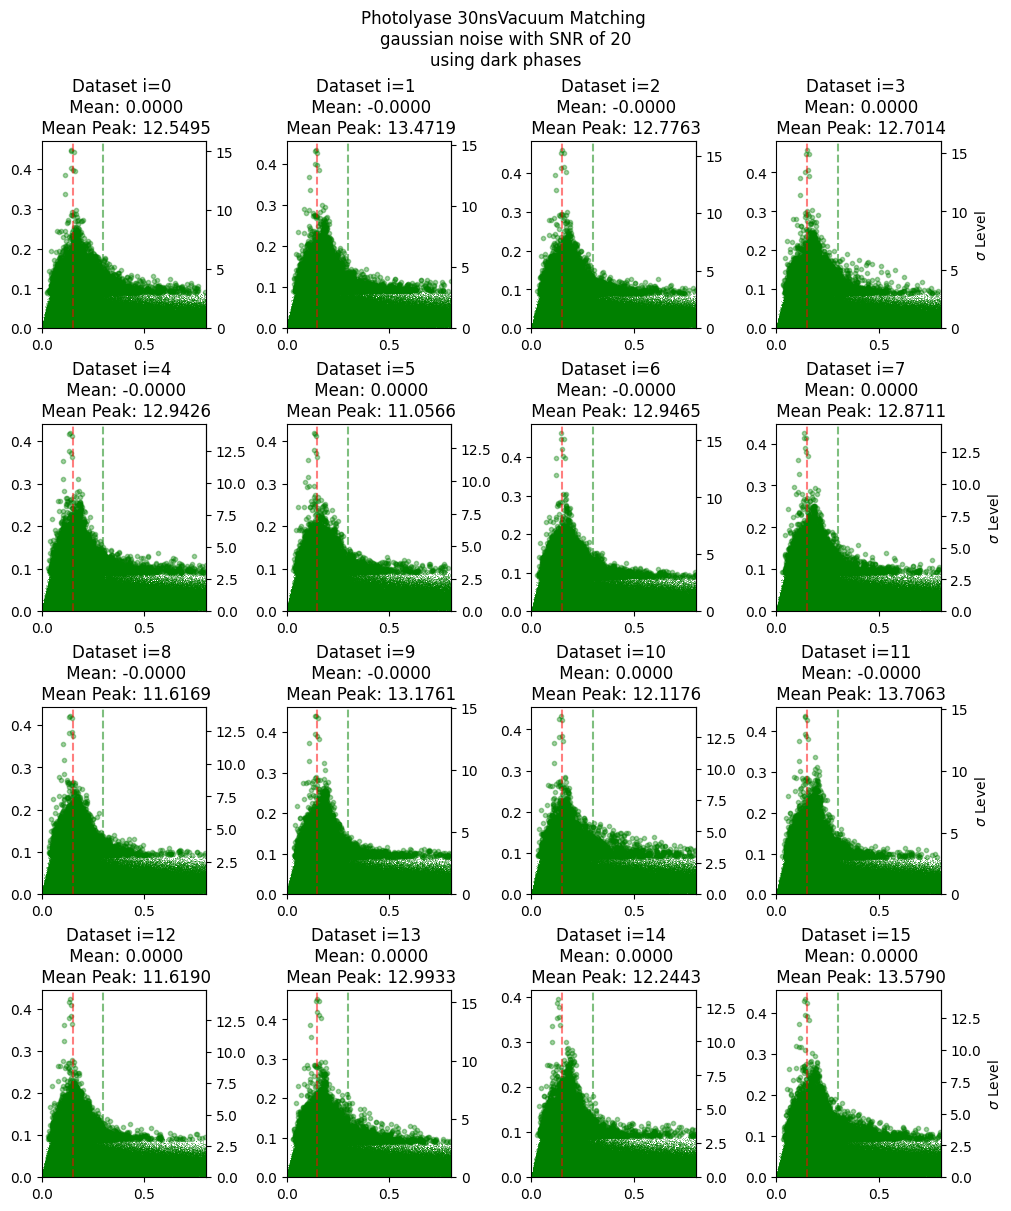

In [25]:
%matplotlib inline
import numpy as np
xmin = 0
ymin = 0
xmax = 0.8

fig, axs = plt.subplots(4,4, figsize=(10,12), constrained_layout = True)
for i, (dl, ax) in enumerate(zip(list_of_dicts, axs.flat)):
    pseudo = dl['pseudo_occupancy']
    diff = -dl['diffmap_np']
    
    
    # 2. Calculate stats LOCALLY for this specific subplot
    current_mean = np.mean(diff)
    current_std = np.std(diff)
    current_mean_peak = np.mean(diff[clean_mask]) - default_mean
    print(i, current_mean)
    
    # 3. Define the transformation functions with local closure
    # We use default arguments to "snap" the current mean/std into the function
    def abs_to_std(y, m=current_mean, s=current_std):
        return (y - m) / s

    def std_to_abs(z, m=current_mean, s=current_std):
        return (z * s) + m
    sig3 = std_to_abs(3)
    mask = np.logical_and.reduce([diff > ymin, pseudo > xmin, pseudo < xmax])
    mask_main = np.logical_and(mask, diff<sig3)
    mask_outlier = np.logical_and(mask, diff>=sig3)
    
    # 1. Plot the data
    ax.plot(pseudo[mask_outlier], diff[mask_outlier], '.', color='green', alpha=0.1)
    ax.plot(pseudo[mask_main], diff[mask_main], ',', color='green', alpha=0.1)


    # 4. Vertical lines and limits
    ax.axvline(true_occupancy/2, color='red', linestyle='--', alpha=0.5)
    ax.axvline(true_occupancy, color='green', linestyle='--', alpha=0.5)
    ax.set_ylim(0, None)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"Dataset i={i} \n Mean: {current_mean*100:.4f}\n Mean Peak: {current_mean_peak*100:.4f}")
    secax = ax.secondary_yaxis('right', functions=(abs_to_std, std_to_abs))
    if (i + 1) % 4 == 0: 
        secax.set_ylabel(r"$\sigma$ Level", fontsize=10)
    # secax.set_ylabel(r"Standard Deviations ($\sigma$)")

title = "Photolyase 30ns"
title += f"Vacuum Matching \n{options['noise_type']} noise with SNR of {options["snr_factor"]}\n"
title += f"using {'dark' if options['dark_phases'] else 'true'} phases"
_ =fig.suptitle(title)

In [26]:
diff_clean, map_dark_clean, map_light_clean = mix_maps(
    pdbloc_pl_dark,
    pdbloc_pl_light,
    high_resolution_limit=1.5,
    dark_phases=False,
    snr_factor=0,
    true_occupancy=true_occupancy
)

diff_clean_dark, _, _ = mix_maps(
    pdbloc_pl_dark,
    pdbloc_pl_light,
    high_resolution_limit=1.5,
    dark_phases=True,
    snr_factor=0,
    true_occupancy=true_occupancy
)
diff_clean_np = diff_clean.to_3d_numpy_map(map_sampling=3)
diff_clean_dark_np = diff_clean_dark.to_3d_numpy_map(map_sampling=3)
clean_mask = np.abs(diff_clean_np) >0.1
default_mean = np.mean(diff_clean_dark_np[clean_mask])


Text(0.5, 0, 'Clean Difference Map Values')

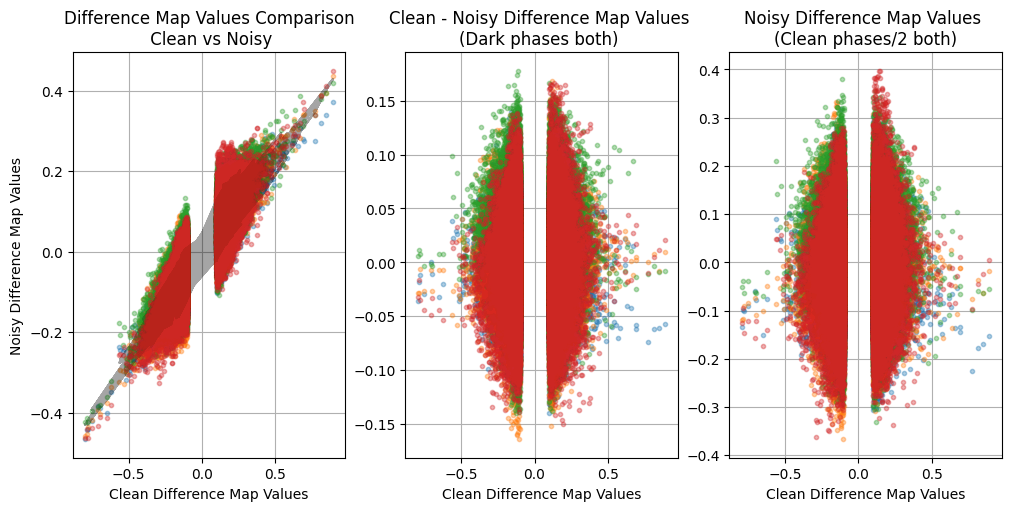

In [22]:
default_mean = np.mean(diff_clean_np[clean_mask])
fig, axs = plt.subplots(1,3, figsize = (10,5), constrained_layout=True)
for i, (dl) in enumerate((list_of_dicts)):
    if i in [1,13,8,6,]:
        pseudo = dl['pseudo_occupancy']
        diff = dl['diffmap_np']
        axs[0].plot(diff_clean_np[clean_mask], diff[clean_mask], '.', alpha=0.1)
        axs[0].plot(diff_clean_np[clean_mask], diff_clean_dark_np[clean_mask], '-k', alpha=0.1)
        axs[1].plot(diff_clean_np[clean_mask], diff[clean_mask]-diff_clean_dark_np[clean_mask], '.', alpha=0.1)
        axs[2].plot(diff_clean_np[clean_mask], 2*diff[clean_mask]-diff_clean_np[clean_mask], '.', alpha=0.1)
axs[0].set_xlabel("Clean Difference Map Values")
axs[0].set_ylabel("Noisy Difference Map Values")
axs[0].set_title("Difference Map Values Comparison\n Clean vs Noisy")
axs[1].set_xlabel("")
axs[1].set_title("Clean - Noisy Difference Map Values \n(Dark phases both) ")
axs[2].set_title("Noisy Difference Map Values \n(Clean phases/2 both)")

axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].set_xlabel("Clean Difference Map Values")
axs[1].set_xlabel("Clean Difference Map Values")
axs[2].set_xlabel("Clean Difference Map Values")


In [ ]:

    ax.set_title()
    ax.axvline(0.135)
    ax.axvline(0.27)
    ax.set_ylim(0, None)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"          i={i}")

# plt.figure()
# idx = 9
# vmax = np.max(np.abs(diffmap_np[idx]))
# plt.imshow(
#     diffmap_np[idx], cmap='bwr', vmin = -vmax, vmax=vmax
# )
# plt.colorbar()


In [87]:
diff_deviant = list_of_dicts[10]['diffmap']
print(diff_deviant)
diff_close = list_of_dicts[8]['diffmap']

                F         PHI
H  K L                       
0  0 1        NaN  300.587524
     2  15.749023         0.0
     3        NaN  330.777985
     4 -37.891525  180.000015
     5        NaN   28.810629
...           ...         ...
34 7 2        NaN  121.900787
     3        NaN     0.04032
     4        NaN    0.414682
   8 0        NaN     0.00003
     1        NaN  101.837654

[38599 rows x 2 columns]


In [ ]:
diff_deviant[diff_deviant.compute_dHKL()>20].head(20)
diff_deviant[np.abs(diff_deviant["F"])>500]

F         PHI
H  K  L                         
0  0  2   799.627576         0.0
   1  3   246.798977       270.0
   2  1   562.181201    0.000003
      2   687.176435  180.000015
      11  209.441193  180.000015
...              ...         ...
11 11 7   218.207395  226.796234
      16  250.788325   39.206161
13 1  8   226.976911  136.006897
15 7  14  236.423323  220.640518
16 5  3   230.492811  345.812683

[71 rows x 2 columns]

In [ ]:
diff_close[diff_close.compute_dHKL()>20].head(20)
diff_close[np.abs(diff_close["F"])>500]

F         PHI
H K  L                         
0 0  2   911.098128         0.0
  4  0  -536.625203         0.0
1 0  1  -725.881006        90.0
     3  -650.915108       270.0
  4  0  -535.746338       270.0
2 2  4    528.74675   96.799515
3 11 14 -500.155448  280.986542
6 2  15 -581.007116  263.801239

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

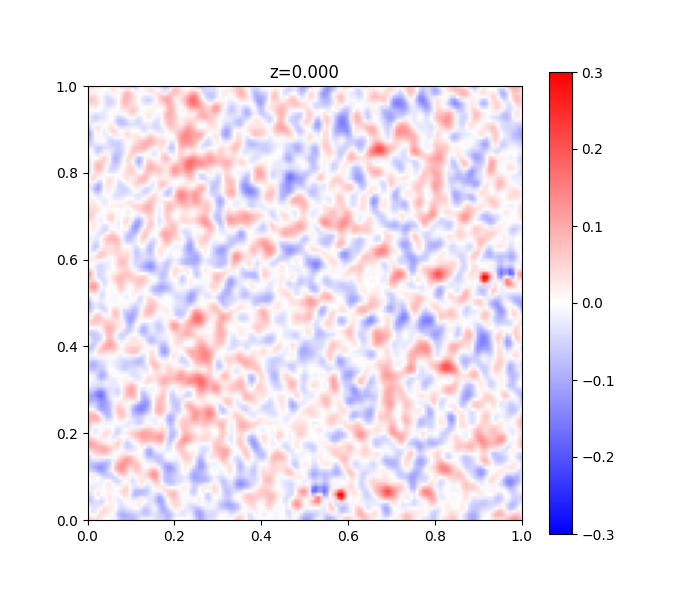

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

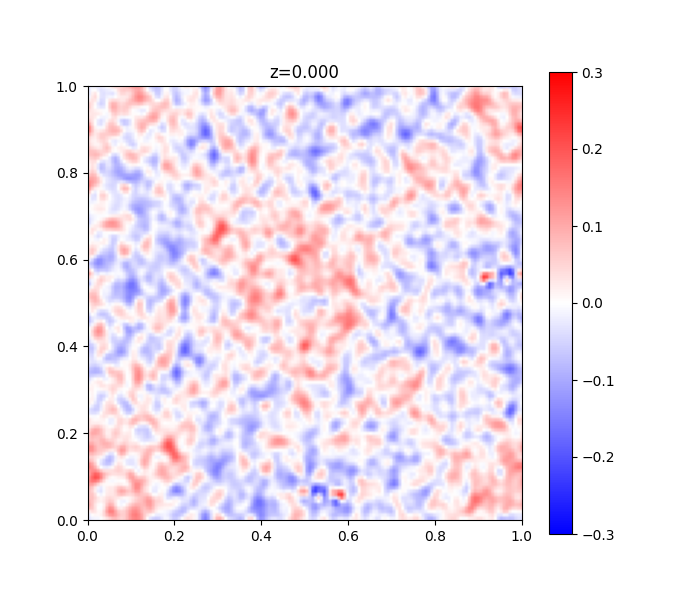

In [11]:
%matplotlib widget
from plotting3d import slice_3d
imkwargs=dict(vmin = -0.3, vmax=0.3, cmap='bwr')
_ = slice_3d(diff_close.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)
plt.show()
_ = slice_3d(diff_deviant.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

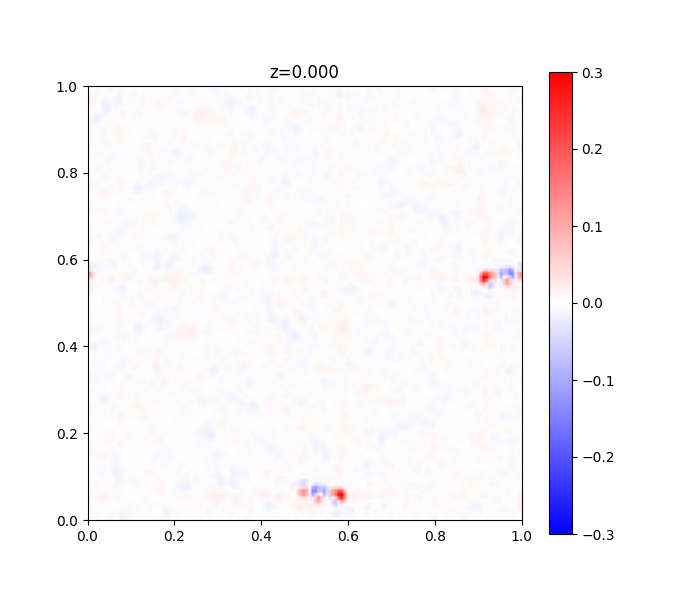

In [17]:
_ =slice_3d(diff_clean.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)

In [ ]:
deviant_dict = list_of_dicts[4]
map_dark_dev = deviant_dict['map_dark_np'] 
diffmap_dev = deviant_dict['diffmap_np'] 

In [56]:
occus = [0.08, .135, .17, 0.2, .24, .4, .8, 5]
from skimage.feature import match_template 
p_devs = []
p_darks = []
mask = np.abs((map_light_np - map_dark_np))>0.2
for occu in occus:
    map_xtr_believe = map_dark_dev + 1/occu * diffmap_dev
    p_dev = match_template(map_xtr_believe, map_light_np)
    p_dark = match_template(map_xtr_believe, map_dark_np)
    p_devs.append(p_dev[0][0][0])
    p_darks.append(p_dark[0][0][0])
